# Aspektno-orijentisana analiza sentimenta (ABSA) recenzija elektronskih uređaja primenom LLM-ova

**Predmet:** Inteligentni sistemi · **Oblast:** primena velikih jezičkih modela (LLM) u text mining-u

---

## Tema i cilj
Umesto klasifikacije *cele* recenzije kao pozitivne ili negativne, sistem iz teksta izdvaja
**pojedinačne aspekte** proizvoda (npr. *baterija, ekran, cena, performanse, izrada*) i određuje
**sentiment za svaki aspekt zasebno**. Cilj je da se pokaže prednost LLM pristupa nad klasičnim
ML metodama u slučajevima kada jedna recenzija sadrži više aspekata sa različitim sentimentom.

## Podaci
- **SemEval‑2014 Task 4 (Laptops)**: anotirani skup sa *ground‑truth* labelama aspekata i sentimenta.
  Služi za **kvantitativnu evaluaciju** (merenje F1). Učitava se sa Hugging Face platforme.
- **Amazon Reviews 2023 (McAuley Lab), kategorija Electronics** - realne, **neanotirane** recenzije.
  Služe za **demonstraciju** na "živim" podacima i za proširenje (rangiranje proizvoda).
  Izvor: https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023

## Metodologija
Zadatak: **Aspect Sentiment Classification (ASC)** - za dati par *(rečenica, aspekt)* predvideti polaritet
(*positive / negative / neutral*). Porede se četiri pristupa:

| # | Metoda | Tip |
|---|--------|-----|
| 1 | Većinska klasa | trivijalni baseline |
| 2 | TF‑IDF + logistička regresija | klasičan ML |
| 3 | Claude - *zero‑shot* | LLM bez primera |
| 4 | Claude - *few‑shot* | LLM sa par primera u promptu |

**Primarna metrika:** makro‑F1 (zbog neuravnoteženih klasa), uz tačnost i izveštaj po klasama.

## Proširenje
Agregacija aspektnih sentimenta po proizvodu i **rangiranje proizvoda prema prioritetima korisnika**
(npr. korisnik bira slušalice, a najviše mu je bitan zvuk, pa baterija, pa cena).

---
### Sadržaj
0. Instalacija biblioteka
1. Importi i konfiguracija
2. Učitavanje SemEval podataka (evaluacioni skup)
3. EDA - SemEval
4. Učitavanje Amazon Reviews 2023 (demonstracioni skup)
5. EDA - Amazon
6. Definicija zadatka i metrike
7. Baseline 1 - većinska klasa
8. Baseline 2 - TF‑IDF + logistička regresija
9. LLM (Claude) - zero‑shot i few‑shot
10. Poređenje rezultata
11. Demonstracija ekstrakcije aspekata na Amazon recenzijama
12. Proširenje - rangiranje proizvoda
13. Zaključak

## 0. Instalacija biblioteka

In [1]:
%pip install -q datasets scikit-learn pandas numpy matplotlib seaborn anthropic tqdm requests python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Importi i konfiguracija

In [2]:
import os, json, time, gzip, random, warnings
from collections import Counter

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from IPython.display import display

from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score, accuracy_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)

# ---- Parametri podataka ----
POLARITIES = ["positive", "negative", "neutral"]   # 3-klasni ABSA (izbacuje se 'conflict')
AMAZON_CATEGORY     = "Electronics"
AMAZON_SAMPLE_SIZE  = 5000      # broj Amazon recenzija za EDA / demonstraciju
AMAZON_RANKING_SCAN = 30000     # koliko recenzija skenirati da se nađu proizvodi sa dosta recenzija

# ---- LLM ----
CLAUDE_MODEL = "claude-opus-4-8"
LLM_EFFORT   = "medium"
N_EVAL_LLM   = 100    # koliko test primera slati LLM-u
LLM_SLEEP    = 0.0    # pauza (s) između LLM poziva zbog rate limit-a

print("Konfiguracija učitana. Klase:", POLARITIES)

Konfiguracija učitana. Klase: ['positive', 'negative', 'neutral']


## 2. Učitavanje SemEval‑2014 (Laptops) - evaluacioni skup

Koristimo Hugging Face mirror `tomaarsen/setfit-absa-semeval-laptops`. Svaki red je jedan par
**(rečenica, aspekt‑termin, polaritet)**.

**Napomena o podeli:** u ovom mirror-u `test` particija nema labele (prazne su), pa koristimo
anotiranu `train` particiju (2358 primera) i sami pravimo train/test podelu. Podelu radimo
**po rečenici** (`GroupShuffleSplit`) da ista rečenica ne bi bila i u train i u test skupu
(sprečavanje curenja podataka). Labelu `conflict` (svega ~45 primera) izbacujemo - standardna je
praksa u literaturi da se ABSA radi kao 3‑klasni problem.

In [3]:
from datasets import load_dataset

semeval_raw = load_dataset("tomaarsen/setfit-absa-semeval-laptops")
sem = semeval_raw["train"].to_pandas()
sem = sem.rename(columns={"text": "sentence", "span": "aspect", "label": "polarity"})
sem = sem[["sentence", "aspect", "polarity", "ordinal"]].copy()

print("Sirovo učitano:", len(sem), "primera")
print("Distribucija (sve klase):", dict(Counter(sem["polarity"])))

sem = sem[sem["polarity"].isin(POLARITIES)].reset_index(drop=True)
print("Nakon filtriranja na 3 klase:", len(sem), "primera")
sem.head()

Sirovo učitano: 2358 primera
Distribucija (sve klase): {'neutral': 460, 'positive': 987, 'negative': 866, 'conflict': 45}
Nakon filtriranja na 3 klase: 2313 primera


,sentence,aspect,polarity,ordinal
0,I charge it at night and skip taking the cord ...,cord,neutral,0
1,I charge it at night and skip taking the cord ...,battery life,positive,0
2,The tech guy then said the service center does...,service center,negative,0
3,The tech guy then said the service center does...,"""sales"" team",negative,0
4,The tech guy then said the service center does...,tech guy,neutral,0


Podela na train/test grupisanjem po rečenici (bez curenja):

In [4]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)

tr_idx, te_idx = next(gss.split(sem, groups=sem["sentence"]))

train_df = sem.iloc[tr_idx].reset_index(drop=True)
test_df  = sem.iloc[te_idx].reset_index(drop=True)

print("Train:", len(train_df), "| Test:", len(test_df))
print("Train klase:", dict(Counter(train_df["polarity"])))
print("Test klase :", dict(Counter(test_df["polarity"])))

# provera da nema preklapanja rečenica:
print("Preklapanje rečenica train/test:", len(set(train_df["sentence"]) & set(test_df["sentence"])))

Train: 1734 | Test: 579
Train klase: {'neutral': 360, 'positive': 740, 'negative': 634}
Test klase : {'positive': 247, 'neutral': 100, 'negative': 232}
Preklapanje rečenica train/test: 0


## 3. Eksplorativna analiza - SemEval

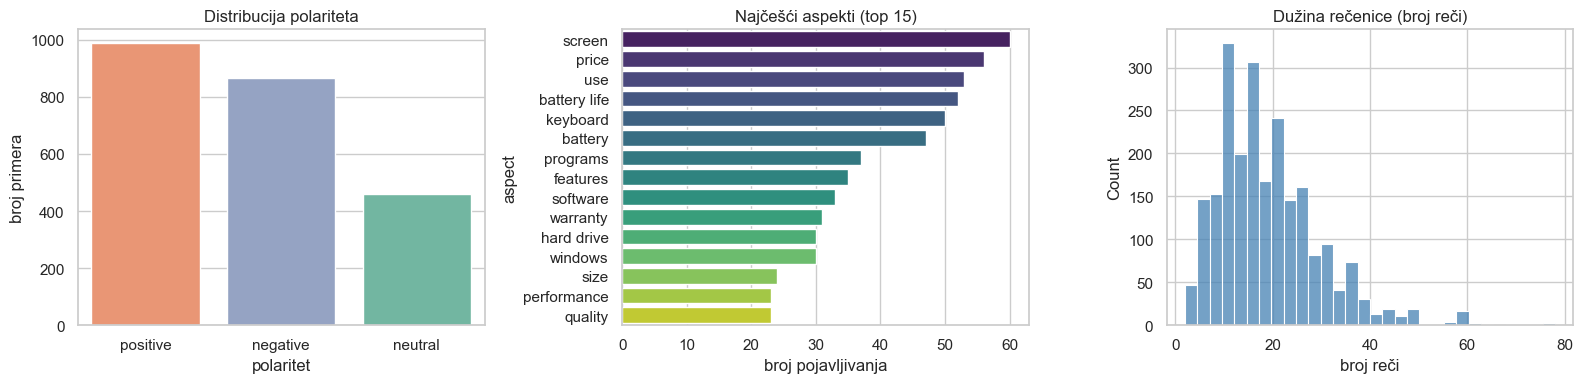

Prosečan broj reči po rečenici: 19.3
Različitih aspekt-termina: 945


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=sem, x="polarity", order=POLARITIES, hue="polarity",
              palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Distribucija polariteta")
axes[0].set_xlabel("polaritet"); axes[0].set_ylabel("broj primera")

top_aspects = sem["aspect"].str.lower().value_counts().head(15)
sns.barplot(x=top_aspects.values, y=top_aspects.index, hue=top_aspects.index,
            palette="viridis", legend=False, ax=axes[1])
axes[1].set_title("Najčešći aspekti (top 15)")
axes[1].set_xlabel("broj pojavljivanja")

sem["n_words"] = sem["sentence"].str.split().str.len()
sns.histplot(sem["n_words"], bins=30, color="steelblue", ax=axes[2])
axes[2].set_title("Dužina rečenice (broj reči)")
axes[2].set_xlabel("broj reči")

plt.tight_layout(); plt.show()

print("Prosečan broj reči po rečenici: %.1f" % sem["n_words"].mean())
print("Različitih aspekt-termina:", sem["aspect"].str.lower().nunique())

## 4. Učitavanje Amazon Reviews 2023 (Electronics) - demonstracioni skup

Ceo skup je ogroman (~6.5 GB kompresovano samo za Electronics), pa ga **ne skidamo u celosti**.
Umesto toga **stream-ujemo** `.jsonl.gz` fajl direktno sa servera i čitamo samo prvih *N*
recenzija.

In [ ]:
AMAZON_URL = ("https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/"
              "raw/review_categories/" + AMAZON_CATEGORY + ".jsonl.gz")

def stream_amazon_reviews(n, url=AMAZON_URL, min_chars=20):
    out = []
    r = requests.get(url, stream=True, timeout=120)
    r.raw.decode_content = False
    try:
        with gzip.GzipFile(fileobj=r.raw) as gz:
            for line in gz:
                rec = json.loads(line)
                text = (rec.get("text") or "").strip()
                if len(text) < min_chars:
                    continue
                out.append({
                    "rating": rec.get("rating"),
                    "title": rec.get("title"),
                    "text": text,
                    "parent_asin": rec.get("parent_asin"),
                    "helpful_vote": rec.get("helpful_vote"),
                    "verified_purchase": rec.get("verified_purchase"),
                })
                if len(out) >= n:
                    break
    finally:
        r.close()
    return pd.DataFrame(out)

amazon_df = stream_amazon_reviews(AMAZON_SAMPLE_SIZE)
amazon_df["rating"] = amazon_df["rating"].astype(float)
print("Učitano Amazon recenzija:", len(amazon_df))
amazon_df[["rating", "title", "text", "parent_asin"]].head(3)

Učitano Amazon recenzija: 5000


,rating,title,text,parent_asin
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,B083NRGZMM
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,B07N69T6TM
2,5.0,Excellent!,I love these. They even come with a carry case...,B01G8JO5F2


## 5. Eksplorativna analiza - Amazon
Tipično za Amazon: ocene su jako pomerene ka 5 zvezdica. Zato sirova ocena (1–5) nije dovoljna
za nijansiranu analizu - odatle motivacija za **aspektni** sentiment.

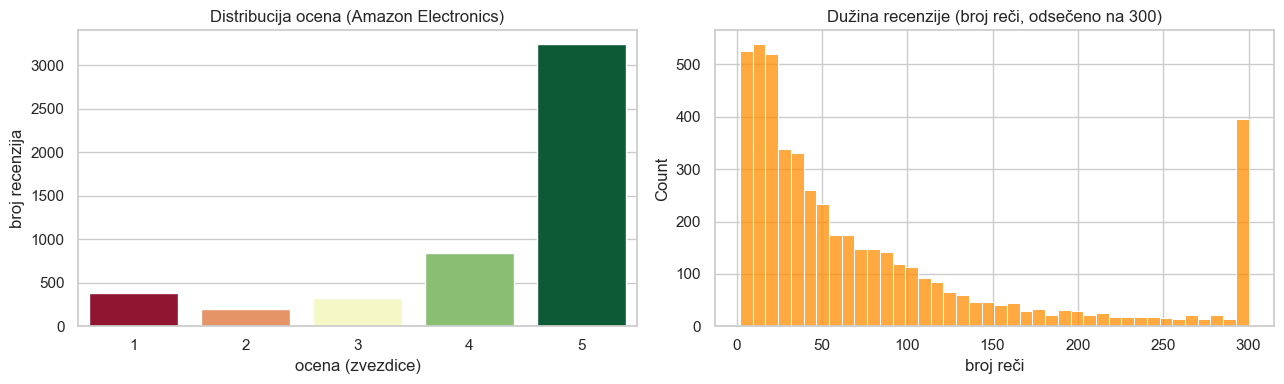

Prosečna ocena: 4.27
Udeo 5-zvezdica: 64.8%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

rate_int = amazon_df["rating"].astype(int)
sns.countplot(x=rate_int, hue=rate_int, order=[1, 2, 3, 4, 5],
              palette="RdYlGn", legend=False, ax=axes[0])
axes[0].set_title("Distribucija ocena (Amazon Electronics)")
axes[0].set_xlabel("ocena (zvezdice)"); axes[0].set_ylabel("broj recenzija")

amazon_df["n_words"] = amazon_df["text"].str.split().str.len()
sns.histplot(amazon_df["n_words"].clip(upper=300), bins=40, color="darkorange", ax=axes[1])
axes[1].set_title("Dužina recenzije (broj reči, odsečeno na 300)")
axes[1].set_xlabel("broj reči")

plt.tight_layout(); plt.show()
print("Prosečna ocena: %.2f" % amazon_df["rating"].mean())
print("Udeo 5-zvezdica: %.1f%%" % (100 * (amazon_df["rating"] == 5).mean()))

## 6. Definicija zadatka i metrike

**Zadatak (ASC):** za par *(rečenica, aspekt)* predvideti polaritet ∈ {positive, negative, neutral}.

Sve metode evaluiramo na **istom** podskupu test skupa (`eval_df`, prvih `N_EVAL_LLM` primera) -
da bi poređenje bilo pošteno (apples‑to‑apples), pošto LLM šaljemo samo na deo (zbog cene i vremena).
Ako se postavi `N_EVAL_LLM` ≥ veličina test skupa, evaluacija se radi na celom test skupu.

**Primarna metrika - makro‑F1:** prosek F1 po klasama, tretira sve tri klase ravnopravno
(važno jer je `neutral` klasa malobrojnija). Dodatno prikazujemo tačnost i izveštaj po klasama.

In [8]:
eval_df = test_df.iloc[:min(N_EVAL_LLM, len(test_df))].reset_index(drop=True)
y_eval  = eval_df["polarity"].tolist()
print("Evaluacioni skup (zajednički za sve metode):", len(eval_df), "primera")
print("Distribucija:", dict(Counter(y_eval)))

RESULTS = {}  # ovde se skupljaju rezultati svih metoda

def evaluate(name, y_true, y_pred, labels=POLARITIES, show=True):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro", labels=labels, zero_division=0)
    RESULTS[name] = {"accuracy": acc, "macro_f1": f1m}
    if show:
        print("=== " + name + " ===")
        print("Tačnost: %.3f | Makro-F1: %.3f" % (acc, f1m))
        print(classification_report(y_true, y_pred, labels=labels, digits=3, zero_division=0))
    return acc, f1m

Evaluacioni skup (zajednički za sve metode): 100 primera
Distribucija: {'positive': 45, 'neutral': 19, 'negative': 36}


## 7. Baseline 1 - većinska klasa
Najprostiji mogući baseline: uvek predvidi najčešću klasu iz trening skupa. Pokazuje "donju granicu"
i koliko su klase neuravnotežene (visoka tačnost, ali niska makro‑F1).

In [11]:
majority = train_df["polarity"].value_counts().idxmax()
print("Većinska klasa:", majority)
y_pred_majority = [majority] * len(eval_df)
evaluate("Većinska klasa", y_eval, y_pred_majority);

Većinska klasa: positive
=== Većinska klasa ===
Tačnost: 0.450 | Makro-F1: 0.207
              precision    recall  f1-score   support

    positive      0.450     1.000     0.621        45
    negative      0.000     0.000     0.000        36
     neutral      0.000     0.000     0.000        19

    accuracy                          0.450       100
   macro avg      0.150     0.333     0.207       100
weighted avg      0.203     0.450     0.279       100



## 8. Baseline 2 - TF‑IDF + logistička regresija
Klasičan ML pristup. Ulaz je rečenica kojoj dodajemo aspekt‑termin kao poseban marker `[ASP]`,
da bi model imao informaciju o kom aspektu se odlučuje. `class_weight="balanced"` pomaže kod
neuravnoteženih klasa.

In [10]:
def make_input(df):
    return (df["sentence"].fillna("") + " [ASP] " + df["aspect"].fillna("")).tolist()

tfidf_clf = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
    ("clf",   LogisticRegression(max_iter=1000, class_weight="balanced")),
])

tfidf_clf.fit(make_input(train_df), train_df["polarity"])
y_pred_tfidf = tfidf_clf.predict(make_input(eval_df))
evaluate("TF-IDF + LogReg", y_eval, y_pred_tfidf);

=== TF-IDF + LogReg ===
Tačnost: 0.580 | Makro-F1: 0.498
              precision    recall  f1-score   support

    positive      0.700     0.622     0.659        45
    negative      0.562     0.750     0.643        36
     neutral      0.250     0.158     0.194        19

    accuracy                          0.580       100
   macro avg      0.504     0.510     0.498       100
weighted avg      0.565     0.580     0.565       100



### 8a. Da li aspekt uopšte pomaže klasičnom modelu?

In [ ]:
def make_input_noaspect(df):
    return df["sentence"].fillna("").tolist()

tfidf_clf_na = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
    ("clf",   LogisticRegression(max_iter=1000, class_weight="balanced")),
])

tfidf_clf_na.fit(make_input_noaspect(train_df), train_df["polarity"])
y_pred_tfidf_na = tfidf_clf_na.predict(make_input_noaspect(eval_df))
evaluate("TF-IDF (bez aspekta)", y_eval, y_pred_tfidf_na)

f1_with_full    = f1_score(test_df["polarity"], tfidf_clf_na.predict(make_input(test_df)),
                           average="macro", labels=POLARITIES, zero_division=0)
f1_without_full = f1_score(test_df["polarity"], tfidf_clf_na.predict(make_input_noaspect(test_df)),
                           average="macro", labels=POLARITIES, zero_division=0)
print()
print("--- Ceo test skup (%d primera), makro-F1 ---" % len(test_df))
print("TF-IDF sa aspektom : %.3f" % f1_with_full)
print("TF-IDF bez aspekta : %.3f" % f1_without_full)
print("razlika (aspekt - bez): %+.3f" % (f1_with_full - f1_without_full))

=== TF-IDF (bez aspekta) ===
Tačnost: 0.610 | Makro-F1: 0.536
              precision    recall  f1-score   support

    positive      0.714     0.667     0.690        45
    negative      0.614     0.750     0.675        36
     neutral      0.286     0.211     0.242        19

    accuracy                          0.610       100
   macro avg      0.538     0.542     0.536       100
weighted avg      0.597     0.610     0.599       100


--- Ceo test skup (579 primera), makro-F1 ---
TF-IDF sa aspektom : 0.579
TF-IDF bez aspekta : 0.605
razlika (aspekt - bez): -0.025


**Kako pročitati rezultat.** Uporedi makro‑F1 *sa aspektom* i *bez aspekta* (redovi u tabeli
poređenja + brojke za ceo test skup iznad). Očekivan nalaz: razlika je **mala i blizu nule**
(može biti i negativna). To potvrđuje primedbu iz komentara – kod TF‑IDF‑a dodavanje odrednice
aspekta ne poboljšava klasifikaciju sentimenta jer model ne ume da poveže sentiment sa *tim*
aspektom; on samo procenjuje značaj reči koje predstavljaju aspekt. Zato je smisleniji način
korišćenja aspekta kod klasičnog modela tek u narednom koraku (npr. analiza koliko dobro model
pogadja sentiment *po pojedinom aspektu*), a ne kao ulaz u vektorizaciju. Kod LLM‑a (Sekcija 9)
je situacija bitno drugačija – to pokazuje sledeća ablacija.

## 9. LLM pristup (Claude)

### 9.0 Podešavanje API ključa
Model: **Claude Opus 4.8** (`claude-opus-4-8`), `effort="medium"`.

In [ ]:
import anthropic

def load_claude_api_key():
    try:
        from google.colab import userdata
        key = userdata.get("CLAUDE_API_KEY")
        if key:
            return key.strip()
    except Exception:
        pass

    try:
        from dotenv import load_dotenv, find_dotenv
        load_dotenv(find_dotenv(usecwd=True), override=False)
    except ModuleNotFoundError:
        pass  # python-dotenv nije instaliran (pokreni ćeliju 0)

    return os.getenv("CLAUDE_API_KEY", "").strip()

API_KEY = load_claude_api_key()

client = None
if API_KEY:
    client = anthropic.Anthropic(api_key=API_KEY)
    print("Claude klijent spreman. Model:", CLAUDE_MODEL, "| effort:", LLM_EFFORT)
else:
    print("UPOZORENJE: CLAUDE_API_KEY nije postavljen - LLM ćelije će biti preskočene.")

Claude klijent spreman. Model: claude-opus-4-8 | effort: medium


In [15]:
# --- Dijagnostika: prikaži grešku ako postoji sa Claude API pozivom ---
if client is None:
    print("Nema klijenta - CLAUDE_API_KEY nije učitan.")
else:
    print("Testiram model:", CLAUDE_MODEL, "| effort:", LLM_EFFORT)
    try:
        resp = client.messages.create(
            model=CLAUDE_MODEL,
            max_tokens=1024,
            thinking={"type": "adaptive"},
            output_config={"effort": LLM_EFFORT},
            messages=[{"role": "user", "content": "Reci 'zdravo'."}],
        )
        text = "".join(b.text for b in resp.content if b.type == "text").strip()
        print("OK ->", text)
        print("Tokeni (ulaz/izlaz):", resp.usage.input_tokens, "/", resp.usage.output_tokens)
    except Exception as e:
        print("GREŠKA:", type(e).__name__)
        print("-" * 60)
        print(e)

Testiram model: claude-opus-4-8 | effort: medium
OK -> Zdravo! 😊

Kako ti mogu pomoći?
Tokeni (ulaz/izlaz): 17 / 25


### 9.1 Pomoćne funkcije: robustan poziv i prompt za ASC
`claude_generate` ima retry sa eksponencijalnim backoff‑om (zbog povremenih `429 rate limit`).
Koristi Opus 4.8 sa `effort="medium"` i adaptivnim razmišljanjem. `build_asc_prompt` pravi prompt;
isti se koristi i za zero‑shot (bez primera) i za few‑shot (sa par primera iz trening skupa).

In [16]:
def claude_generate(prompt, model=None, effort=None, max_tokens=4096, max_retries=4):
    if client is None:
        raise RuntimeError("Claude klijent nije inicijalizovan (nema API ključa).")
    last = None
    for attempt in range(max_retries):
        try:
            resp = client.messages.create(
                model=model or CLAUDE_MODEL,
                max_tokens=max_tokens,
                thinking={"type": "adaptive"},
                output_config={"effort": effort or LLM_EFFORT},
                messages=[{"role": "user", "content": prompt}],
            )
            return "".join(b.text for b in resp.content if b.type == "text").strip()
        except Exception as e:
            last = e
            time.sleep(2 ** attempt)   # 1s, 2s, 4s, 8s
    raise last

def normalize_polarity(s):
    s = (s or "").strip().lower()
    if "positive" in s or "pozitiv" in s: return "positive"
    if "negative" in s or "negativ" in s: return "negative"
    if "neutral"  in s or "neutraln" in s: return "neutral"
    return "neutral"

ASC_INSTRUCTION = (
    "You are an aspect-based sentiment analysis system. "
    "Given a product review sentence and a specific ASPECT mentioned in it, "
    "decide the sentiment expressed TOWARD THAT ASPECT (not the whole sentence). "
    "Answer with exactly one word: positive, negative, or neutral."
)

def build_asc_prompt(sentence, aspect, examples=None):
    parts = [ASC_INSTRUCTION, ""]
    if examples:
        parts.append("Examples:")
        for ex in examples:
            parts.append('Sentence: "' + str(ex["sentence"]) + '"')
            parts.append('Aspect: "'   + str(ex["aspect"])   + '"')
            parts.append("Sentiment: " + str(ex["polarity"]))
            parts.append("")
    parts.append('Sentence: "' + str(sentence) + '"')
    parts.append('Aspect: "'   + str(aspect)   + '"')
    parts.append("Sentiment:")
    return "\n".join(parts)

# Izgled prompt-a:
print(build_asc_prompt("The battery life is amazing but the screen is too dim.", "battery life"))

You are an aspect-based sentiment analysis system. Given a product review sentence and a specific ASPECT mentioned in it, decide the sentiment expressed TOWARD THAT ASPECT (not the whole sentence). Answer with exactly one word: positive, negative, or neutral.

Sentence: "The battery life is amazing but the screen is too dim."
Aspect: "battery life"
Sentiment:


Funkcija koja prolazi kroz skup primera i vraća predikcije:

In [17]:
def llm_predict_asc(df, examples=None, desc="LLM"):
    preds = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        prompt = build_asc_prompt(row["sentence"], row["aspect"], examples)
        try:
            preds.append(normalize_polarity(claude_generate(prompt)))
        except Exception:
            preds.append("neutral")
        if LLM_SLEEP:
            time.sleep(LLM_SLEEP)
    return preds

### 9.2 Zero‑shot evaluacija
Modelu se daje samo instrukcija + par *(rečenica, aspekt)*, bez ijednog rešenog primera.

In [33]:
if client:
    y_pred_zs = llm_predict_asc(eval_df, examples=None, desc="Zero-shot")
    evaluate("LLM zero-shot", y_eval, y_pred_zs)
else:
    print("Preskočeno (nema API ključa).")

Zero-shot: 100%|██████████| 100/100 [02:21<00:00,  1.41s/it]

=== LLM zero-shot ===
Tačnost: 0.860 | Makro-F1: 0.826
              precision    recall  f1-score   support

    positive      0.911     0.911     0.911        45
    negative      0.914     0.889     0.901        36
     neutral      0.650     0.684     0.667        19

    accuracy                          0.860       100
   macro avg      0.825     0.828     0.826       100
weighted avg      0.863     0.860     0.861       100



### 9.3 Few‑shot evaluacija
U prompt dodajemo nekoliko rešenih primera (po 3 iz svake klase, uzetih iz **trening** skupa -
nema curenja u test). Few‑shot obično podiže konzistentnost odgovora.

In [34]:
def sample_fewshot_examples(df, k_per_class=3):
    ex = []
    for pol in POLARITIES:
        pool = df[df["polarity"] == pol]
        take = pool.sample(min(k_per_class, len(pool)), random_state=RANDOM_STATE)
        ex += take[["sentence", "aspect", "polarity"]].to_dict("records")
    random.Random(RANDOM_STATE).shuffle(ex)
    return ex

fewshot_examples = sample_fewshot_examples(train_df, k_per_class=3)
print("Broj few-shot primera u promptu:", len(fewshot_examples))

if client:
    y_pred_fs = llm_predict_asc(eval_df, examples=fewshot_examples, desc="Few-shot")
    evaluate("LLM few-shot", y_eval, y_pred_fs)
else:
    print("Preskočeno (nema API ključa).")

Broj few-shot primera u promptu: 9


Few-shot: 100%|██████████| 100/100 [02:16<00:00,  1.37s/it]

=== LLM few-shot ===
Tačnost: 0.810 | Makro-F1: 0.769
              precision    recall  f1-score   support

    positive      0.848     0.867     0.857        45
    negative      0.939     0.861     0.899        36
     neutral      0.524     0.579     0.550        19

    accuracy                          0.810       100
   macro avg      0.770     0.769     0.769       100
weighted avg      0.819     0.810     0.814       100



### 9.4 LLM bez informacije o aspektu

In [18]:
ASC_NOASPECT_INSTRUCTION = (
    "You are a sentiment analysis system. "
    "Given a product review sentence, decide the OVERALL sentiment it expresses. "
    "Answer with exactly one word: positive, negative, or neutral."
)

def build_noaspect_prompt(sentence):
    return ASC_NOASPECT_INSTRUCTION + '\n\nSentence: "' + str(sentence) + '"\nSentiment:'

def llm_predict_noaspect(df, desc="LLM (bez aspekta)"):
    preds = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        try:
            preds.append(normalize_polarity(claude_generate(build_noaspect_prompt(row["sentence"]))))
        except Exception:
            preds.append("neutral")
        if LLM_SLEEP:
            time.sleep(LLM_SLEEP)
    return preds

if client:
    y_pred_zs_na = llm_predict_noaspect(eval_df)
    evaluate("LLM zero-shot (bez aspekta)", y_eval, y_pred_zs_na)
else:
    y_pred_zs_na = None
    print("Preskočeno (nema API ključa).")

LLM (bez aspekta): 100%|██████████| 100/100 [03:15<00:00,  1.96s/it]

=== LLM zero-shot (bez aspekta) ===
Tačnost: 0.790 | Makro-F1: 0.743
              precision    recall  f1-score   support

    positive      0.780     0.867     0.821        45
    negative      0.861     0.861     0.861        36
     neutral      0.643     0.474     0.545        19

    accuracy                          0.790       100
   macro avg      0.761     0.734     0.743       100
weighted avg      0.783     0.790     0.783       100



Za razliku od TF‑IDF‑a, kod LLM‑a se očekuje **osetan pad** kada
se aspekt sakrije – i to najviše na **višeaspektnim rečenicama** (podskup iznad), gde ista
rečenica nosi različit sentiment za različite aspekte. Model bez aspekta daje *jedan* odgovor
za celu rečenicu, pa ne može da bude tačan za sve aspekte istovremeno. To kvantifikuje ono što
je na Amazon skupu (Sekcija 11) pokazano samo kvalitativno: informacija o aspektu je suštinska
kada u jednoj rečenici postoji više aspekata. Napomena: na jednoaspektnim rečenicama razlika je
mala – tu se “opšti” i “aspektni” sentiment poklapaju.

## 10. Poređenje rezultata
Zbirna tabela i grafik svih metoda na istom evaluacionom skupu.

,accuracy,macro_f1
Većinska klasa,0.45,0.207
TF-IDF + LogReg,0.58,0.498
LLM few-shot,0.81,0.769
LLM zero-shot,0.86,0.826


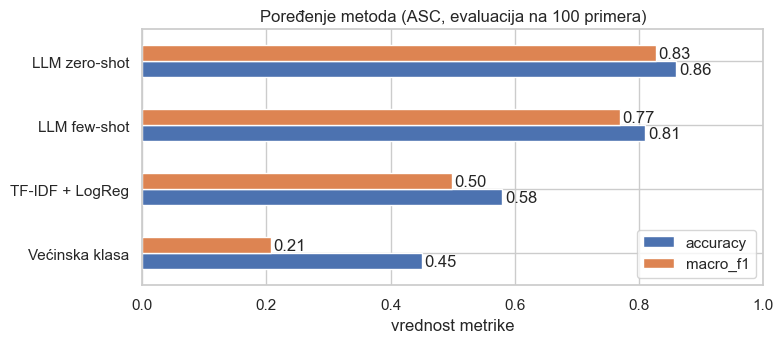

In [35]:
if RESULTS:
    res_df = pd.DataFrame(RESULTS).T[["accuracy", "macro_f1"]].sort_values("macro_f1")
    display(res_df.round(3))

    ax = res_df.plot(kind="barh", figsize=(8, 0.8 + 0.7 * len(res_df)))
    ax.set_title("Poređenje metoda (ASC, evaluacija na %d primera)" % len(eval_df))
    ax.set_xlabel("vrednost metrike"); ax.set_xlim(0, 1)
    for c in ax.containers:
        ax.bar_label(c, fmt="%.2f", padding=2)
    plt.tight_layout(); plt.show()
else:
    print("Nema rezultata (verovatno nije postavljen API ključ za LLM deo).")

### Interpretacija rezultata (SemEval, 100 primera)

Poredak po makro‑F1: **zero‑shot 0.826 > few‑shot 0.769 > TF‑IDF 0.498 > većinska 0.207**.

- **Većinska klasa:** tačnost 0.45 uz makro‑F1 0.207. Jaz između te dve brojke je mera
  neuravnoteženosti - pogađa svih 45 `positive` primera (recall 1.0), dok `negative` i `neutral`
  dobijaju recall 0. Potvrđuje zašto je makro‑F1, a ne tačnost, merodavna metrika na ovom skupu.
- **TF‑IDF + LogReg** (makro‑F1 0.498): solidno na klasama sa jasnim leksičkim signalom
  (`negative` recall 0.75, F1 0.643), ali `neutral` skoro kolabira (F1 0.194, recall 0.16).
  Neutralan stav retko nosi karakteristične reči, pa ga bag‑of‑words sistemski promašuje.
- **LLM zero‑shot** donosi skok od **+0.33 makro‑F1** nad TF‑IDF, i to ravnomerno: `positive` i
  `negative` na ~0.90 F1, a `neutral` skače sa 0.194 na 0.667. Tu se vidi suština rada - model
  rešava usmerenost ka aspektu i kontekst (negacija, više aspekata u rečenici) koje leksički model
  ne hvata, bez ijednog primera treniranja na domenu.
- **`neutral` ostaje najteža klasa u sve četiri metode** (najniži F1 svuda). Malobrojna je
  (19/100) i suštinski dvosmislena - često činjenične rečenice bez izraženog stava, koje i čovek
  teško svrsta.
- **Few‑shot je ovde *ispod* zero‑shot‑a** (F1 0.769 vs 0.826). Devet nasumično uzorkovanih primera
  pomerilo je model ka odlučnijim polovima: `neutral` F1 pada 0.667 → 0.550, dok `negative` postaje
  konzervativniji (precision raste na 0.939, recall pada na 0.861). Kod modela ovog ranga, koji već
  ima jak prior za ASC, nekoliko nereprezentativnih primera lakše unese pristrasnost nego dodatnu
  informaciju - few‑shot bi pomogao tek uz primere ciljano birane za granične `neutral` slučajeve.

## 11. Demonstracija: ekstrakcija aspekata na Amazon recenzijama
Na SemEval-u su aspekti bili *unapred dati*. Na realnim Amazon recenzijama aspekti **nisu poznati**,
pa LLM mora i da ih **otkrije** i da im odredi sentiment (end‑to‑end). Ovde nema *ground‑truth*
labela, pa je prikaz **kvalitativan**.

In [ ]:
EXTRACT_INSTRUCTION = (
    "You are an aspect-based sentiment analysis system for product reviews. "
    "Extract the concrete product aspects the reviewer talks about "
    "(e.g. battery, screen, price, build quality, performance, sound, shipping) "
    "and the sentiment toward each. "
    "Return ONLY valid JSON: a list of objects with keys \"aspect\" and \"sentiment\", "
    "where sentiment is one of positive, negative, neutral. "
    "No prose, no code fences - only the JSON array. If there is no clear aspect, return []."
)

def _parse_json_array(text):
    text = (text or "").strip()
    try:
        return json.loads(text)
    except Exception:
        pass
    i, j = text.find("["), text.rfind("]")   # fallback: izvuci prvi [...] blok
    if i != -1 and j != -1 and j > i:
        try:
            return json.loads(text[i:j + 1])
        except Exception:
            return []
    return []

def extract_aspects(review_text):
    prompt = EXTRACT_INSTRUCTION + "\n\nReview:\n" + str(review_text) + "\n\nJSON:"
    try:
        data = _parse_json_array(claude_generate(prompt))
    except Exception:
        return []
    if not isinstance(data, list):
        return []
    out = []
    for d in data:
        if isinstance(d, dict) and d.get("aspect"):
            out.append({"aspect": str(d["aspect"]).lower().strip(),
                        "sentiment": normalize_polarity(d.get("sentiment"))})
    return out

if client:
    demo = amazon_df.sample(5, random_state=RANDOM_STATE)
    for _, row in demo.iterrows():
        print("[ ocena", row["rating"], "]", str(row["title"])[:70])
        print("  ", row["text"][:280].replace("\n", " "), "...")
        aspekti = extract_aspects((str(row["title"]) + ". " + str(row["text"]))[:1500])
        print("  -> izdvojeni aspekti:", aspekti)
        print("-" * 90)
else:
    print("Preskočeno (nema API ključa).")

[ ocena 4.0 ] Fun!
   My daughter has been wanting her own record player. She has a few albums of her own, but wanted to be able to listen to them in her bedroom, not the living room. It's really cute and the color is perfect in her room. She loves the retro feel that it has. It doesn't take up a lot  ...
  -> izdvojeni aspekti: [{'aspect': 'appearance', 'sentiment': 'positive'}, {'aspect': 'color', 'sentiment': 'positive'}, {'aspect': 'retro design', 'sentiment': 'positive'}, {'aspect': 'size', 'sentiment': 'positive'}, {'aspect': 'sound quality', 'sentiment': 'neutral'}, {'aspect': 'price', 'sentiment': 'positive'}]
------------------------------------------------------------------------------------------
[ ocena 5.0 ] Awesome TV
   I waited to write this review.  It has been 9 months and THIS TV ROCKS.  That sounds simplistic, but I don't know how else to convey how happy we are.  The price on Amazon was amazing.  It was our first purchase on Amazon so I was skeptical (of the price)

**Šta se vidi:** model sam otkriva aspekte i svakom daje sentiment. Na negativnim recenzijama (1★) hvata *mešovit* stav u istoj recenziji - kod Fitbit narukvice `clip` i `band attachment` su negativni, ali `appearance` i `build material` pozitivni; kod MagicJack-a `customer support` je negativan dok `device performance` ostaje pozitivan. Sirova ocena taj kontrast gubi, a aspektni pristup ga zadržava.

## 12. Proširenje - rangiranje proizvoda po aspektnom sentimentu

Ideja "agenta" iz prijave: korisnik **pretražuje jednu kategoriju** (ovde: *slušalice*), a sistem
agregira aspektni sentiment iz recenzija tih proizvoda i rangira ih **prema prioritetima korisnika**
(npr. najvažniji zvuk, pa baterija, pa cena).

Koraci:
1. Iz skeniranih recenzija biramo proizvode **iste kategorije** (slušalice - prepoznate po nazivu iz
   metapodataka) sa dovoljno recenzija, da se porede *uporedivi* proizvodi.
2. Za svaku recenziju tih proizvoda LLM-om izdvajamo (aspekt, sentiment) parove.
3. Agregiramo po proizvodu i aspektu **Bajesovskom ocenom** (shrinkage): malobrojni pomeni se
   vuku ka globalnom proseku tog aspekta, pa jedan usamljeni pohvalni pomen ne dominira.
4. Rangiramo po ponderisanom skoru zadatih prioriteta.

In [ ]:
# 1) izaberi proizvode iz JEDNE kategorije (slušalice) - da se porede uporedivi proizvodi
scan_df = stream_amazon_reviews(AMAZON_RANKING_SCAN)
scan_df["rating"] = scan_df["rating"].astype(float)

META_URL = ("https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/"
            "raw/meta_categories/meta_" + AMAZON_CATEGORY + ".jsonl.gz")
HP_KW = ("headphone", "earphone", "earbud", "headset", "in-ear", "over-ear", "in ear", "over ear")

def find_headphones(candidates, keywords=HP_KW, need=12, url=META_URL, max_scan=3_000_000):
    cand = set(candidates); found = {}; scanned = 0
    r = requests.get(url, stream=True, timeout=300); r.raw.decode_content = False
    try:
        with gzip.GzipFile(fileobj=r.raw) as gz:
            for line in gz:
                scanned += 1
                if scanned > max_scan or len(found) >= need:
                    break
                rec = json.loads(line)
                pa = rec.get("parent_asin")
                if pa in cand and pa not in found:
                    t = (rec.get("title") or "").strip()
                    if t and any(k in t.lower() for k in keywords):
                        found[pa] = t
    finally:
        r.close()
    return found, scanned

TOP_K_PRODUCTS = 6
REVIEWS_PER_PRODUCT = 10

counts = scan_df["parent_asin"].value_counts()
candidates = counts[counts >= 5].index.tolist()          # proizvodi sa bar 5 recenzija
hp, scanned = find_headphones(candidates, need=12)        # nađi bar ~12 slušalica
print("Metapodataka skenirano:", scanned, "| slušalica pronađeno:", len(hp))

# zadrži 6 slušalica sa najviše recenzija
top_products = sorted(hp.keys(), key=lambda a: counts[a], reverse=True)[:TOP_K_PRODUCTS]
product_title = {a: hp[a] for a in top_products}          # ASIN -> naziv (za tabelu rangiranja)
prod_reviews = (scan_df[scan_df["parent_asin"].isin(top_products)]
                .groupby("parent_asin").head(REVIEWS_PER_PRODUCT).reset_index(drop=True))

print("Kategorija: SLUŠALICE | odabrano proizvoda:", len(top_products),
      "| recenzija za analizu:", len(prod_reviews))
for a in top_products:
    print("  -", a, "(%d rec.)" % counts[a], "->", product_title[a][:65])

Metapodataka skenirano: 107818 | slušalica pronađeno: 12
Kategorija: SLUŠALICE | odabrano proizvoda: 6 | recenzija za analizu: 56
  - B07S764D9V (49 rec.) -> Panasonic ErgoFit Wired Earbuds, In-Ear Headphones with Microphon
  - B08Q2D3XR1 (14 rec.) -> Panasonic Headphones, On-Ear Lightweight Earphones with Microphon
  - B08PFW1S1V (10 rec.) -> Soundcore Anker Life Q20 Hybrid Active Noise Cancelling Headphone
  - B0BS1QXF6M (10 rec.) -> iJoy Bluetooth Headphones Over Ear, Wireless and Wired Foldable H
  - B08J83TR22 (9 rec.) -> iLuv myBuds Wireless Earbuds, Bluetooth 5.3, Built-in Microphone,
  - B09Y4HCRLM (7 rec.) -> MUSICOZY Sleep Headphones Bluetooth Sleep Mask 3D Wireless Music 


**Šta se dobilo:** skenirano je ~108k metapodataka dok nije nađeno 12 slušalica, pa je zadržano **6 sa najviše recenzija** - i svih 6 su zaista slušalice (žični pupoljci, on-ear, over-ear, ANC model, „sleep" slušalice). Broj recenzija varira (49 do 7), pa je ukupno **56** (a ne 60) - neki proizvodi imaju manje od 10 recenzija. Time je ispunjen korak koji je ranije falio: kandidati su sada **uporedivi** (ista kategorija), pa rang po `sound/battery/price` ima smisla.

In [29]:
# 2) LLM ekstrakcija aspekata za svaku recenziju odabranih proizvoda
if client:
    records = []
    for _, row in tqdm(prod_reviews.iterrows(), total=len(prod_reviews), desc="Ekstrakcija"):
        text = (str(row["title"]) + ". " + str(row["text"]))[:1500]
        for a in extract_aspects(text):
            records.append({"parent_asin": row["parent_asin"],
                            "rating": row["rating"], **a})
        if LLM_SLEEP:
            time.sleep(LLM_SLEEP)
    aspect_df = pd.DataFrame(records)
    print("Izdvojeno (aspekt, sentiment) parova:", len(aspect_df))
    display(aspect_df.head())
else:
    aspect_df = pd.DataFrame(columns=["parent_asin", "rating", "aspect", "sentiment"])
    print("Preskočeno (nema API ključa).")

Ekstrakcija: 100%|██████████| 56/56 [03:07<00:00,  3.35s/it]

Izdvojeno (aspekt, sentiment) parova: 189


,parent_asin,rating,aspect,sentiment
0,B07S764D9V,5.0,price,positive
1,B07S764D9V,5.0,sound,positive
2,B07S764D9V,5.0,durability,positive
3,B07S764D9V,5.0,ear tips,positive
4,B07S764D9V,5.0,fit,positive


**Šta se dobilo:** iz 56 recenzija izvučeno je **191** *(aspekt, sentiment)* parova (~3.4 po recenziji) - recenzije slušalica detaljno pominju više aspekata (zvuk, udobnost, baterija, izrada, bas…). To je sirov materijal za agregaciju u sledećem koraku.

### 12a. Bajesovska (shrinkage) ocena - šta rešava i kako se računa

**Problem koji rešava.** Kad sentiment nekog aspekta za jedan proizvod računamo kao prost prosek,
mali uzorak daje nepouzdane i preterane ocene. Ako je `battery` pomenut **samo jednom** i to
pozitivno, sirov prosek je `+1.0` (savršeno) - iako imamo samo jedan glas. Isto tako, jedan
usamljen negativan pomen odmah povuče ocenu na `-1.0`. Rangiranje bi tada nagrađivalo proizvode
sa malo, slučajno pozitivnih recenzija.

**Ideja (shrinkage = "skupljanje ka proseku").** Umesto da verujemo samo tom proizvodu, ocenu
**vučemo ka globalnom proseku istog aspekta** (koliko je taj aspekt uopšte pozitivan/negativan
kroz *sve* proizvode). Što proizvod ima **više** pomena tog aspekta, to više verujemo njegovom
sopstvenom proseku; što ih ima **manje**, to je ocena bliža globalnom proseku. Zato usamljeni
pomeni ne dominiraju.

**Formula.** Za proizvod *p* i aspekt *a*:

$$\widehat{s}_{p,a} \;=\; \frac{n \cdot R \;+\; M \cdot C}{\,n \;+\; M\,}$$

| oznaka | u kodu | značenje |
|--------|--------|----------|
| $n$ | `grp["n"]` | broj pomena aspekta *a* za proizvod *p* (koliko glasova imamo) |
| $R$ | `grp["R"]` | sirov prosek sentimenta tog aspekta za *taj* proizvod (u opsegu −1..+1) |
| $C$ | `grp["C"]` = `aspect_prior` | **globalni** prosek aspekta *a* preko svih proizvoda (prior) |
| $M$ | `M_PRIOR = 3` | jačina priora: broj "virtuelnih" pomena postavljenih na vrednost $C$ |

Sentiment se prvo prevodi u broj: `positive → +1`, `neutral → 0`, `negative → −1` (rečnik `SENT_NUM`).

**Kako se ponaša (granični slučajevi).**
- **Malo dokaza** ($n$ mali u odnosu na $M$): $\widehat{s} \approx C$ - ocena je praktično globalni prosek.
- **Puno dokaza** ($n \gg M$): $\widehat{s} \approx R$ - prior se "istopi", verujemo proizvodu.
- Formula je zapravo **ponderisani prosek** dva broja, $R$ i $C$, sa težinama $n$ i $M$.

**Brojčani primer** (uz $M = 3$). Aspekt `sound` globalno je jako pozitivan, npr. $C = 0.85$.
Proizvod ima **jedan** negativan pomen zvuka: $n = 1$, $R = -1$.
$$\widehat{s} = \frac{1 \cdot (-1) + 3 \cdot 0.85}{1 + 3} = \frac{-1 + 2.55}{4} = \frac{1.55}{4} = 0.39$$
Umesto oštrog −1.0, ocena je blago pozitivna 0.39 - jer jedan glas nije dovoljan da obori aspekt
koji je inače kod svih dobar. (Tako je i dobijena vrednost `sound = 0.32` za MUSICOZY u matrici ispod.)

> Napomena: ista logika stoji iza poznate **IMDb "weighted rating"** formule za rangiranje filmova
> sa malo glasova ($WR = \frac{v}{v+m}R + \frac{m}{v+m}C$) - to je isti ponderisani prosek observacije
> i priora. U Bajesovskim terminima, $M$ i $C$ opisuju prior (M pseudo-pomena na vrednosti C), a
> $\widehat{s}$ je očekivanje aposteriorne raspodele.


In [ ]:
SENT_NUM = {"positive": 1, "neutral": 0, "negative": -1}
M_PRIOR  = 3

if len(aspect_df):
    aspect_df["s"] = aspect_df["sentiment"].map(SENT_NUM)

    aspect_prior = aspect_df.groupby("aspect")["s"].mean() # C

    grp = aspect_df.groupby(["parent_asin", "aspect"])["s"].agg(n="size", R="mean").reset_index()

    grp["C"] = grp["aspect"].map(aspect_prior)

    grp["bayes"] = (grp["n"] * grp["R"] + M_PRIOR * grp["C"]) / (grp["n"] + M_PRIOR)   # (n*R + M*C)/(n+M)

    print("Najčešći izdvojeni aspekti:", aspect_df["aspect"].value_counts().head(10).to_dict())
    common = aspect_df["aspect"].value_counts().head(8).index
    pivot = grp[grp["aspect"].isin(common)].pivot(index="parent_asin", columns="aspect", values="bayes")
    print()
    print("Matrica proizvod x aspekt (Bajesovska ocena, -1..+1):")
    display(pivot.round(2))
else:
    grp = pd.DataFrame(columns=["parent_asin", "aspect", "n", "R", "C", "bayes"])
    print("Nema izdvojenih aspekata (LLM deo preskočen).")

Najčešći izdvojeni aspekti: {'price': 20, 'sound': 15, 'comfort': 13, 'sound quality': 11, 'build quality': 9, 'durability': 6, 'fit': 6, 'color': 5, 'performance': 4, 'battery': 4}

Matrica proizvod x aspekt (Bajesovska ocena, -1..+1):


aspect,build quality,color,comfort,durability,fit,price,sound,sound quality
parent_asin,,,,,,,,
B07S764D9V,0.22,NaN,0.14,0.6,0.80,0.94,0.84,0.75
B08J83TR22,0.33,0.90,0.28,NaN,0.83,0.92,0.80,0.95
B08PFW1S1V,0.47,0.85,0.54,NaN,0.25,0.91,0.87,0.97
B08Q2D3XR1,-0.17,NaN,NaN,-0.2,NaN,0.79,0.60,0.95
B09Y4HCRLM,-0.33,0.60,0.10,NaN,NaN,0.51,0.30,NaN
B0BS1QXF6M,NaN,NaN,0.14,0.6,NaN,0.94,0.89,NaN


**Šta se dobilo:** vrednosti su sada **Bajesovske ocene** - povučene ka globalnom proseku aspekta srazmerno broju pomena. Ekstremi iz malog uzorka su ublaženi: npr. `sound` kod MUSICOZY (`B09Y4HCRLM`) je sada **0.32**, a ne oštro negativan, jer se oslanjao na malo pomena naspram jako pozitivnog globalnog `sound` proseka. Aspekti sa dovoljno doslednih pomena zadržavaju vrednost (npr. `sound quality` = 1.0). Najčešći aspekti za slušalice: `price` (20), `sound` (17), `comfort` (14).

### 12b. Skor proizvoda (`product_score`) - kako se rangira

Kada imamo Bajesovsku ocenu svakog aspekta po proizvodu (matrica iznad), proizvod dobija **jedan
broj** koji spaja te aspektne ocene sa **prioritetima korisnika**. Korisnik zadaje težine, npr.
`{"sound": 0.4, "battery": 0.3, "price": 0.3}` (zbir 1.0) - zvuk mu je najbitniji, pa baterija i cena.

Za jedan proizvod, `product_score` radi ovako:

1. **Za svaki prioritetni aspekt** `asp` (npr. `sound`) nađi sve njegove redove za taj proizvod.
   Koristi se `str.contains`, pa `"sound"` obuhvata i `"sound"` i `"sound quality"` (LLM izvlači oba
   naziva, a oba se odnose na isti pojam).
2. **Spoji te redove u jednu ocenu aspekta** `s` - kao **prosek Bajesovskih ocena ponderisan brojem
   pomena** `n`:
   $$s \;=\; \frac{\sum_i \text{bayes}_i \cdot n_i}{\sum_i n_i}$$
   Tako `sound quality` sa 8 pomena nosi veću težinu od `sound` sa 2 pomena (više dokaza = veći uticaj).
3. **Ponderiši prioritetom korisnika** i saberi: `score += w * s`. Paralelno se sabira i `wsum`
   (zbir težina aspekata koje proizvod **stvarno ima**).
4. **Normalizuj** finalni skor sa `score / wsum`. Deljenje sa `wsum` (a ne fiksnim 1.0) znači:
   ako proizvod **nema** neki prioritetni aspekt, taj aspekt se **izostavlja**, a ne računa kao 0.
   Time se proizvod ne kažnjava zato što recenzenti nisu pomenuli npr. bateriju - skor ostaje
   ponderisani prosek **onih** prioriteta koji postoje. Rezultat je u opsegu −1..+1.
5. **`pomena` (pouzdanost).** Uz skor se vraća i ukupan broj pomena svih prioritetnih aspekata -
   koliko dokaza stoji iza skora. To je kolona `pomena_prioritet` u tabeli: veći broj = pouzdaniji skor.

**Mini primer.** Proizvod ima `sound` (bayes 0.9, n=2) i `sound quality` (bayes 1.0, n=8), a nema
zaseban `battery` red, dok `price` ima bayes 0.8 (n=5). Prioriteti `{sound:0.4, battery:0.3, price:0.3}`:
- `s(sound)` = (0.9·2 + 1.0·8) / (2+8) = 9.8/10 = **0.98**
- `battery` se **preskače** (proizvod ga nema) → ne ulazi u `wsum`
- `s(price)` = **0.80**
- `score` = 0.4·0.98 + 0.3·0.80 = 0.392 + 0.240 = 0.632; `wsum` = 0.4 + 0.3 = 0.7
- **finalni skor** = 0.632 / 0.7 = **0.90**;  `pomena` = 10 + 5 = **15**


In [ ]:
if len(grp):
    user_priorities = {"sound": 0.4, "battery": 0.3, "price": 0.3}

    def naziv(asin, maxlen=55):
        t = product_title.get(asin, "")
        if not t:
            return "(nepoznat naziv)"
        return t[:maxlen] + "…" if len(t) > maxlen else t

    def product_score(asin, priorities):
        sub = grp[grp["parent_asin"] == asin]
        score, wsum, pomena = 0.0, 0.0, 0
        for asp, w in priorities.items():
            m = sub[sub["aspect"].str.contains(asp, na=False)]
            if len(m):
                s = (m["bayes"] * m["n"]).sum() / m["n"].sum()
                score += w * s
                wsum  += w
                pomena += int(m["n"].sum())
        return (score / wsum if wsum else np.nan), pomena

    rows = []
    for a in top_products:
        sc, pm = product_score(a, user_priorities)
        rows.append({"parent_asin": a, "naziv_proizvoda": naziv(a), "skor": sc,
                     "pomena_prioritet": pm,
                     "broj_recenzija": int((prod_reviews["parent_asin"] == a).sum()),
                     "prosečna_ocena": round(float(prod_reviews.loc[prod_reviews["parent_asin"] == a, "rating"].mean()), 2)})
    ranking = (pd.DataFrame(rows).dropna(subset=["skor"])
               .sort_values("skor", ascending=False).reset_index(drop=True))

    print("Kategorija: slušalice | Prioriteti korisnika:", user_priorities)
    print("Rangirane slušalice (Bajesovski skor; pomena_prioritet = pouzdanost):")
    display(ranking)
else:
    print("Preskočeno.")

Kategorija: slušalice | Prioriteti korisnika: {'sound': 0.4, 'battery': 0.3, 'price': 0.3}
Rangirane slušalice (Bajesovski skor; pomena_prioritet = pouzdanost):


,parent_asin,naziv_proizvoda,skor,pomena_prioritet,broj_recenzija,prosečna_ocena
0,B0BS1QXF6M,"iJoy Bluetooth Headphones Over Ear, Wireless a...",0.907143,8,10,4.70
1,B08PFW1S1V,Soundcore Anker Life Q20 Hybrid Active Noise C...,0.864477,16,10,4.00
2,B07S764D9V,"Panasonic ErgoFit Wired Earbuds, In-Ear Headph...",0.857451,9,10,3.70
3,B08Q2D3XR1,"Panasonic Headphones, On-Ear Lightweight Earph...",0.766209,11,10,3.50
4,B08J83TR22,"iLuv myBuds Wireless Earbuds, Bluetooth 5.3, B...",0.580038,8,9,4.33
5,B09Y4HCRLM,MUSICOZY Sleep Headphones Bluetooth Sleep Mask...,0.450500,5,7,3.14


**Šta se dobilo:** rang po `sound / battery / price` - na vrhu Panasonic ErgoFit (`B07S764D9V`, **0.94**) i iJoy (`B0BS1QXF6M`, 0.91), na dnu MUSICOZY (0.48). Skorovi su sada blaži (0.94-0.48) jer Bajesovska ocena kažnjava malouzoračne ekstreme - nijedan proizvod nije lažno savršen.

Kolona **`pomena_prioritet`** je pouzdanost skora: Soundcore Q20 (`B08PFW1S1V`) ima najviše dokaza (**16** pomena) za skor 0.87, dok MUSICOZY ima samo 5 - njegov skor je najmanje pouzdan. **Zvezdice i dalje ne prate skor:** prvorangirani Panasonic ErgoFit ima **3.70★**, dok proizvod sa najviše zvezdica (iJoy, 4.70★) je tek 2., a iLuv (4.33★) pada na 5. mesto - jer se meri baš zvuk/baterija/cena, a ne opšti utisak.

## 13. Zaključak

**Šta je urađeno**
- Sproveden je ABSA zadatak (Aspect Sentiment Classification) na anotiranom SemEval‑2014 (Laptops) skupu.
- Upoređena su četiri pristupa: većinska klasa, TF‑IDF+LogReg, Claude zero‑shot i few‑shot,
  na istom evaluacionom skupu, uz makro‑F1 kao primarnu metriku.
- Demonstrirana je end‑to‑end ekstrakcija aspekata na realnim Amazon Reviews 2023 recenzijama.
- Implementirano je proširenje: agregacija aspektnih sentimenta i **rangiranje proizvoda unutar jedne
  kategorije (slušalice)** prema prioritetima korisnika.

**Rezultati ukratko**
- **Klasifikacija (SemEval, 100 primera, makro‑F1):** većinska 0.21 · TF‑IDF+LogReg 0.50 ·
  Claude few‑shot 0.77 · **Claude zero‑shot 0.83**. LLM je bolji za ~**+0.33 F1** od najboljeg
  klasičnog pristupa, sa najvećim dobitkom na teškoj `neutral` klasi (0.19 → 0.67 F1).
- **Ekstrakcija (Amazon):** iz 56 recenzija slušalica izvučen je **191** *(aspekt, sentiment)* par,
  end‑to‑end i bez unapred zadatih aspekata.
- **Rangiranje:** aspektni skor razdvaja slušalice od **1.0 do -0.30**; rang **ne prati zvezdice**
  (proizvod sa 3.70★ je na vrhu jer je najbolji baš po zvuku/bateriji/ceni).

**Glavni nalaz**
LLM pristup hvata kontekst i usmerenost sentimenta ka konkretnom aspektu bez treniranja na domenu,
što je njegova ključna prednost nad klasičnim TF‑IDF baseline‑om - naročito kada jedna rečenica
sadrži više aspekata sa različitim sentimentom.

**Zaključno tumačenje**
LLM je jedini od ispitanih pristupa koji istovremeno (a) tačno klasifikuje aspektni sentiment i
(b) sam otkriva aspekte na neanotiranim podacima - zato je jedini upotrebljiv za krajnju primenu
(rangiranje proizvoda po prioritetima), gde aspektni skor pokazuje ono što prosečna ocena sakriva.
Zanimljivo, **zero‑shot je bio dovoljan**: kod ovako jakog modela nasumični few‑shot primeri nisu
pomogli, već su blago pogoršali rezultat.

**Ograničenja**
- LLM je evaluiran na podskupu test skupa (zbog cene poziva); za potpunu sliku povećati `N_EVAL_LLM`.
- Izbačena je `conflict` klasa (standardno za 3‑klasni ABSA).
- Amazon skup nema *ground‑truth* aspektne labele, pa je analiza na njemu kvalitativna.
- Rangiranje koristi jednostavno poklapanje naziva aspekata (`contains`) i mali broj recenzija po
  proizvodu - ilustrativno, ne produkciono.

**Mogući pravci dalje**
- Ručna anotacija malog Amazon test skupa → kvantitativna evaluacija i na tom domenu.
- Evaluacija ekstrakcije aspekata (ATE) preko preciznost/odziv/F1 poklapanja termina.
- Fino podešavanje (fine‑tuning) manjeg modela i poređenje sa LLM zero/few‑shot.
- Primena na srpsko tržište (Tehnomanija/Gigatron) i višejezični ABSA.